In [4]:
from config import client
import pandas as pd
from graph import plot_bar_graph, plot_line_graph, plot_pie_chart,plot_box_plot,plot_scatter_plot,plot_heatmap,plot_histogram,plot_grouped_box_plot

In [5]:
sale_order_query = """
SELECT * FROM zoho_books_analytics.sales_orders
"""

result = client.query(sale_order_query)

sale_order_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [6]:
sale_order_df.columns

Index(['sales_order_id', 'order_date', 'expected_shipment_date', 'sales_order',
       'status', 'estimate_id', 'sub_total_bcy', 'total_bcy',
       'discount_amount_bcy', 'adjustment_bcy', 'sales_person_id',
       'created_time', 'crm_potential_id', 'reference_number',
       'delivery_method', 'customer_id', 'currency_code', 'exchange_rate',
       'crm_reference_id', 'source', 'discount_type', 'address_id',
       'is_discount_before_tax', 'discount_', 'sub_total_fcy', 'total_fcy',
       'discount_amount_fcy', 'shipping_charge_bcy', 'shipping_charge_fcy',
       'adjustment_fcy', 'notes', 'terms__conditions', 'last_modified_time',
       'shipment_terms', 'final_destination', 'coo', 'eta',
       'customer_lot_code', 'invoiced_status', 'paid_status', 'created_by',
       'shipped_via', 'modified_by', 'warehouse', 'az_po', 'pricelist_id',
       'sales_channel', 'payment_terms_label', 'adjustment_description',
       'payment_terms', 'billback', 'customer_program',
       'shipping

In [7]:
columns_to_drop = ['sales_order_id', 'estimate_id',
       'sales_person_id', 'crm_potential_id', 'reference_number',
        'customer_id', 'currency_code', 'exchange_rate',
       'crm_reference_id', 'source', 'address_id',
       'is_discount_before_tax', 'sub_total_fcy',
        'shipping_charge_bcy', 'shipping_charge_fcy',
       'adjustment_fcy', 'notes', 'terms__conditions',
       'shipment_terms', 'pricelist_id', 'payment_terms_label', 'adjustment_description',
       'payment_terms','shipping_charge_tax_id', 'shipping_charge_tax_amount_fcy',
        'discount_amount_bcy','discount_','sales_channel',]
sale_order_df.drop(columns=columns_to_drop, inplace=True)

In [8]:
sale_order_df['channel'].value_counts()

channel
                30191
Direct Sales    10039
EDI              5421
Name: count, dtype: int64

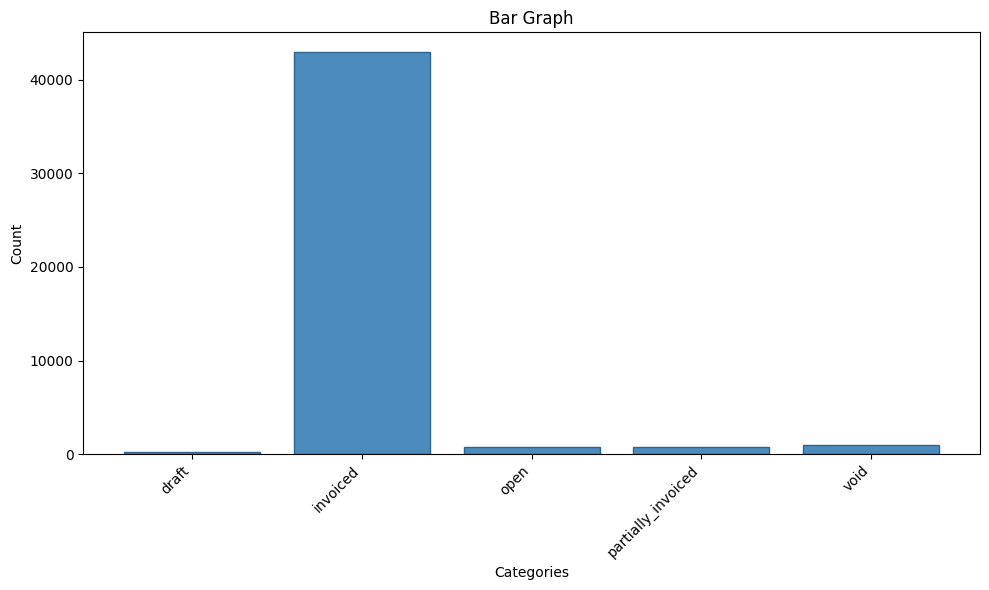

In [9]:
plot_bar_graph(sale_order_df['status'], title="Bar Graph", x_label="Categories", y_label="Count")

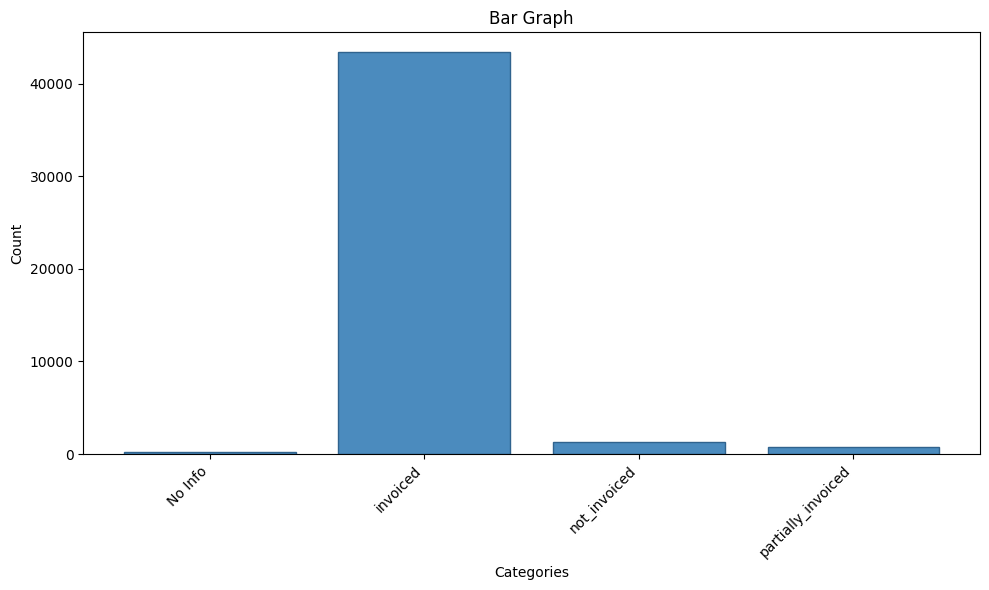

In [10]:
sale_order_df['invoiced_status'] = sale_order_df['invoiced_status'].replace('','No Info')
plot_bar_graph(sale_order_df['invoiced_status'], title="Bar Graph", x_label="Categories", y_label="Count")

In [12]:
# sale_order_df['cleaned_delivery_method'] = sale_order_df['cleaned_delivery_method'].replace('','No Info')
# plot_bar_graph(sale_order_df['cleaned_delivery_method'], title="Bar Graph", x_label="Categories", y_label="Count")

In [13]:
sale_order_df['discount_type'].value_counts()

discount_type
entity_level    45163
item_level        488
Name: count, dtype: int64

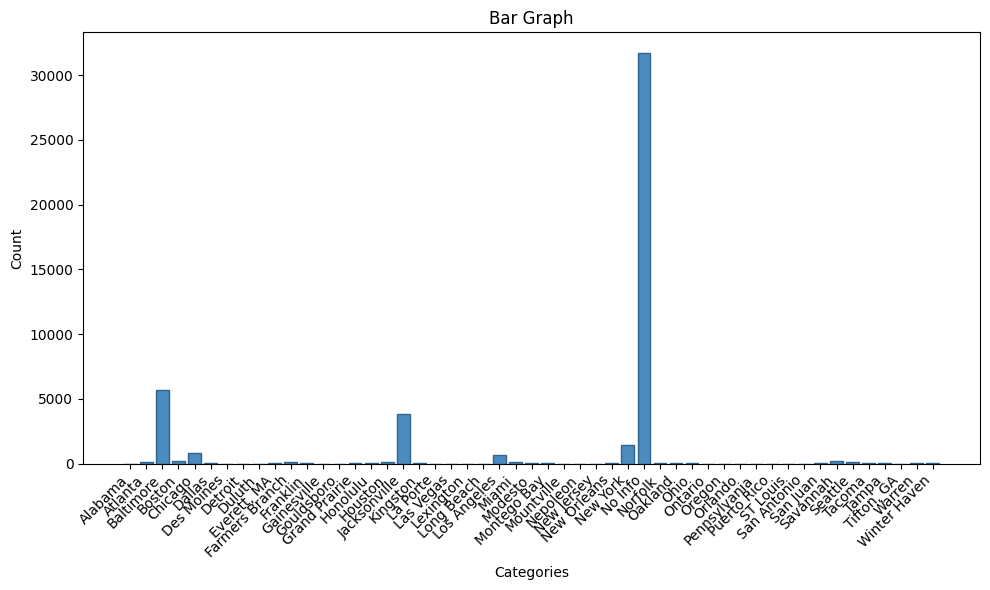

In [14]:
sale_order_df['final_destination'] = sale_order_df['final_destination'].replace('','No Info')
plot_bar_graph(sale_order_df['final_destination'], title="Bar Graph", x_label="Categories", y_label="Count")

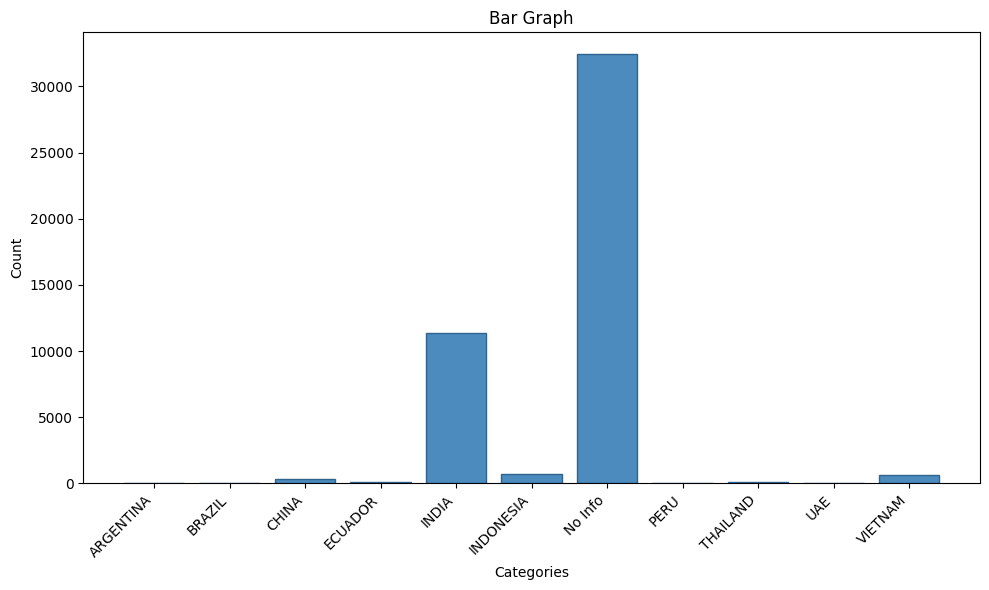

In [15]:
sale_order_df['coo'] = sale_order_df['coo'].replace('','No Info')
plot_bar_graph(sale_order_df['coo'], title="Bar Graph", x_label="Categories", y_label="Count")

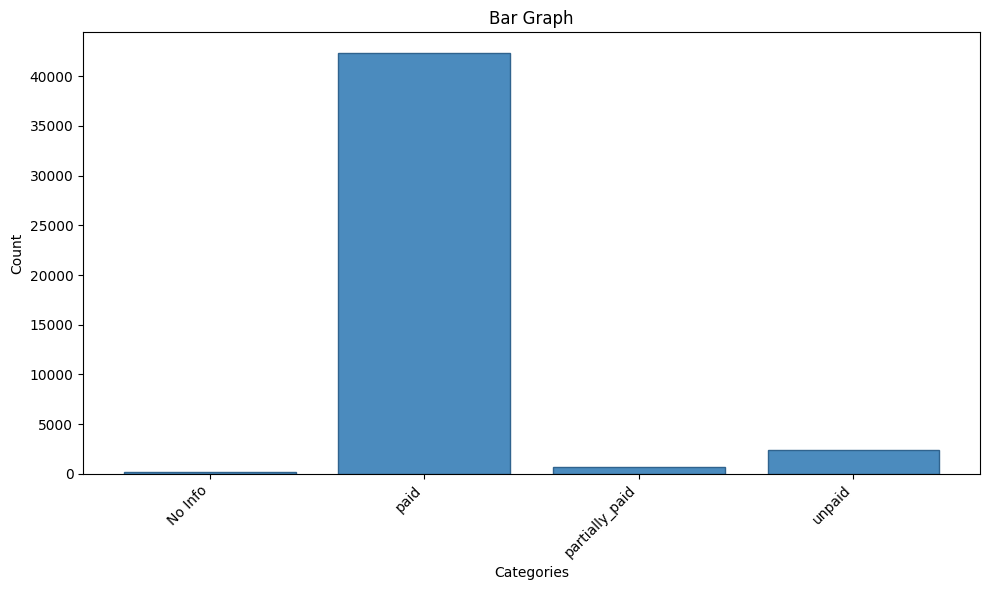

In [16]:
sale_order_df['paid_status'] = sale_order_df['paid_status'].replace('','No Info')
plot_bar_graph(sale_order_df['paid_status'], title="Bar Graph", x_label="Categories", y_label="Count")

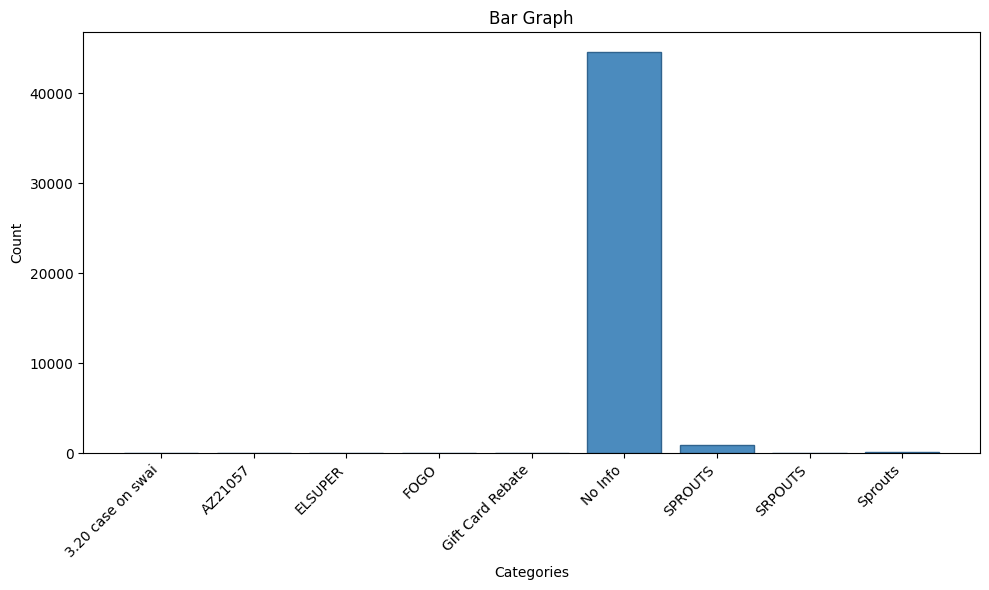

In [17]:
sale_order_df['customer_program'] = sale_order_df['customer_program'].replace('','No Info')
plot_bar_graph(sale_order_df['customer_program'], title="Bar Graph", x_label="Categories", y_label="Count")

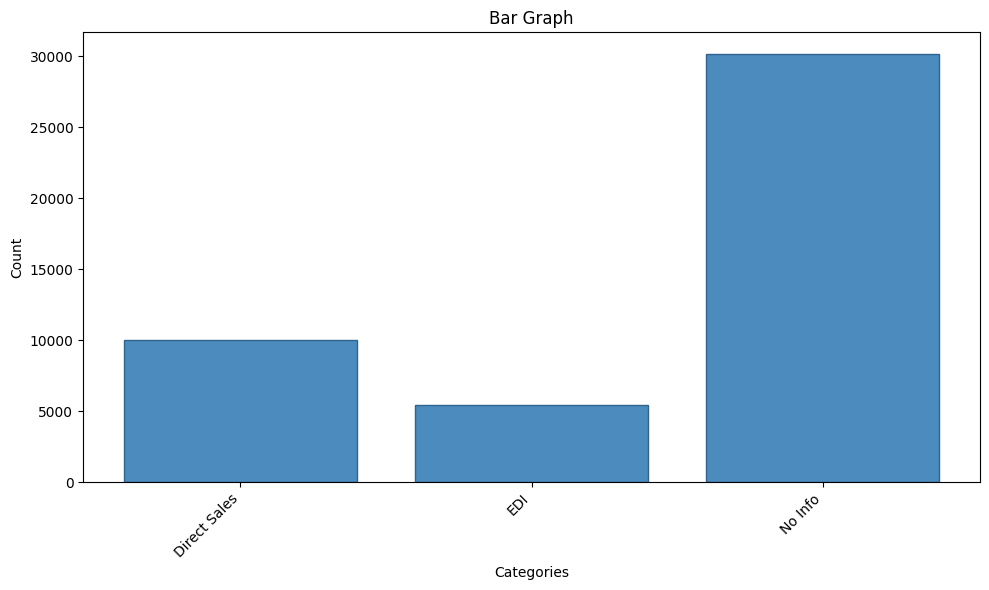

In [18]:
sale_order_df['channel'] = sale_order_df['channel'].replace('','No Info')
plot_bar_graph(sale_order_df['channel'], title="Bar Graph", x_label="Categories", y_label="Count")

In [19]:
df = sale_order_df

In [20]:
pd.to_datetime(df['order_date'])

0       2021-09-10
1       2021-09-20
2       2021-09-20
3       2021-09-20
4       2021-09-20
           ...    
45646   2025-09-23
45647   2023-12-29
45648   2025-09-23
45649   2025-09-23
45650   2025-09-23
Name: order_date, Length: 45651, dtype: datetime64[ns]

In [21]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['expected_shipment_date'] = pd.to_datetime(df['expected_shipment_date'])
df['eta'] = pd.to_datetime(df['eta'])

df['number_of_days_for_delivery'] = (df['eta'] - df['expected_shipment_date']).dt.days  # time taken for delivery from warehouse

In [22]:
# By Status
delay_by_status = df.groupby('invoiced_status')['number_of_days_for_delivery'].mean()
# print("\nAverage Delay by Status:\n", delay_by_status)
delay_by_status

invoiced_status
No Info               33.037037
invoiced              13.895353
not_invoiced          37.220472
partially_invoiced     3.584071
Name: number_of_days_for_delivery, dtype: float64

In [23]:
# By Delivery Method + Shipped Via
delay_by_delivery = df.groupby(['delivery_method', 'shipped_via'])['number_of_days_for_delivery'].mean()  # need to check this
# print("\nAverage Delay by Delivery Method:\n", delay_by_delivery)
delay_by_delivery

delivery_method  shipped_via                  
                                                  20.571429
                 CARLSTADT LOGISTICS               1.000000
                 CUSTOMER WILL ARRANGE DRAYAGE    30.000000
                 Cara-van                          0.000000
                 Caravan                           0.000000
                                                    ...    
TIS              TRANSFSER                              NaN
                 Transfer In Storage               0.000000
                 Transfer in Storage               0.000000
                 Transfer in storage               0.000000
                 tis                                    NaN
Name: number_of_days_for_delivery, Length: 782, dtype: float64

In [24]:
# By Final Destination
delay_by_destination = df.groupby('final_destination')['number_of_days_for_delivery'].mean()
# print("\nAverage Delay by Final Destination:\n", delay_by_destination)
delay_by_destination

final_destination
Alabama                 NaN
Atlanta           35.611111
Baltimore         45.009829
Boston            44.164948
Chicago           43.673130
Dallas            45.105263
Des Moines              NaN
Detroit           35.000000
Duluth                  NaN
Everett, MA       41.333333
Farmers Branch    42.147727
Franklin          36.396226
Gainesville             NaN
Gouldsboro        29.000000
Grand Prairie           NaN
Honolulu          42.636364
Houston           43.613636
Jacksonville      33.600273
Kingston          64.736842
La Porte          31.000000
Las Vegas         38.000000
Lexington         -3.000000
Long Beach        32.000000
Los Angeles       34.042553
Miami             37.708333
Modesto           49.375000
Montego Bay       58.315789
Mountville        40.000000
Nepoleon                NaN
New Jersey         1.000000
New Orleans             NaN
New York          35.850433
No Info            1.660764
Norfolk           37.774194
Oakland           36.909091
Oh

In [25]:
# By COO
delay_by_coo = df.groupby('coo')['number_of_days_for_delivery'].mean()
# print("\nAverage Delay by COO:\n", delay_by_coo)
delay_by_coo

coo
ARGENTINA    39.500000
BRAZIL        1.500000
CHINA        41.181481
ECUADOR      36.972603
INDIA        42.885692
INDONESIA    43.832669
No Info       2.477694
PERU         44.428571
THAILAND     42.285714
UAE                NaN
VIETNAM      39.149171
Name: number_of_days_for_delivery, dtype: float64

In [26]:
delay_by_warehouse = df.groupby('warehouse')['number_of_days_for_delivery'].mean()
# print("\nAverage Delay by Warehouse:\n", delay_by_warehouse)
delay_by_warehouse

warehouse
                                                                                       36.065436
(A6) Lineage Logistics Newark, 360 Avenue P Newark, New Jersey, U.S.A, 07105            1.152542
(A7) Lineage Everett - 60 Commercial Street, Everett, MA 02150, Tel: (617) 387 2050          NaN
(A9) Lineage - LBF, 4901 Bandini Blvd, Vernon, CA 90058                                 0.931973
(A9) Lineage logistics – LBF, 4901 Bandini Blvd, Vernon, CA - 90058                     0.000000
                                                                                         ...    
Summit Cold Storage, 5450 S. Center Ave, Summit, IL 60501, P (708) 924 1137 x240        3.500000
Sunland Distribution of Florida, 5916 Waverly Rd, Lake Wales, FL 33859                  2.419355
UniSea Cold Storage, 15110 NE 90th St Redmond, WA U.S.A, 98052                               NaN
Worldwide Perishables, 50 Eastern Ave. Chelsea, MA  02150                               4.000000
 Lineage - Portsmout

In [27]:
# By Customer Program
delay_by_program = df.groupby('customer_program')['number_of_days_for_delivery'].mean()
# print("\nAverage Delay by Customer Program:\n", delay_by_program)
delay_by_program

customer_program
3.20 case on swai     3.000000
AZ21057                    NaN
ELSUPER               0.000000
FOGO                  4.857143
Gift Card Rebate      0.000000
No Info              14.275665
SPROUTS               6.793103
SRPOUTS                    NaN
Sprouts               3.333333
Name: number_of_days_for_delivery, dtype: float64

In [28]:
# By Channel
delay_by_channel = df.groupby('channel')['number_of_days_for_delivery'].mean()
print("\nAverage Delay by Channel:\n", delay_by_channel)


Average Delay by Channel:
 channel
Direct Sales     3.178422
EDI              2.596710
No Info         21.638460
Name: number_of_days_for_delivery, dtype: float64


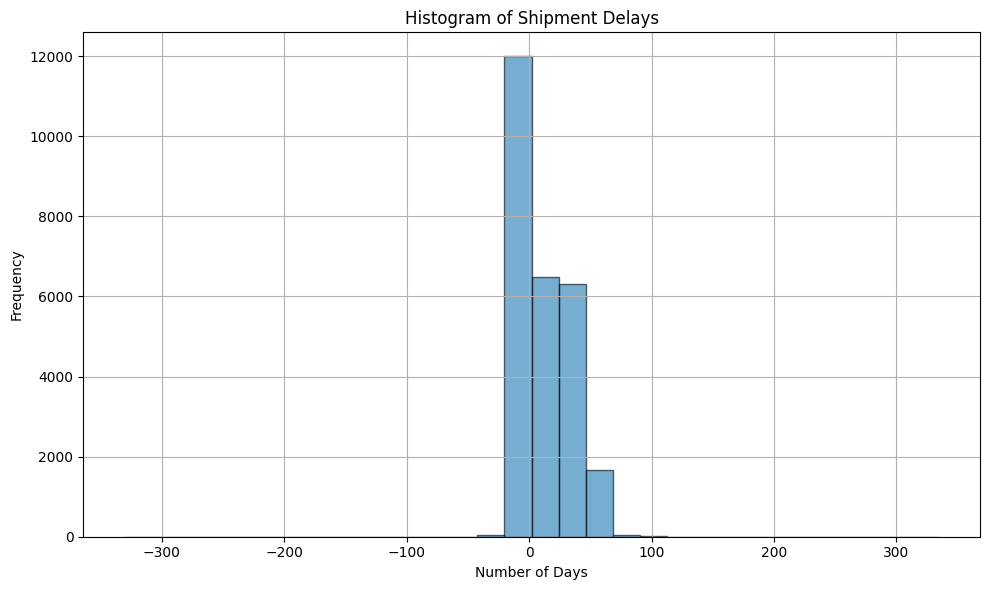

In [29]:
# Values in left of 0 shows inconsistency in data entry where eta < shipment date
plot_histogram(
    df['number_of_days_for_delivery'],
    bins=30,
    title="Histogram of Shipment Delays",
    x_label="Number of Days",
    y_label="Frequency",
    kde=False
)

In [30]:

# number_of_days_for_delivery

In [31]:


# Mapping dictionary
mapping = {
    # Pick Up variations
    "pick up": "Pick Up",
    "pickup": "Pick Up",
    "pick up": "Pick Up",

    # Door Delivered variations
    "door delivered": "Door Delivered",
    "door delivery": "Door Delivered",
    "door deliverd": "Door Delivered",
    "door deliveredb": "Door Delivered",
    "door deliveredb": "Door Delivered",

    # DDP variations
    "ddp": "DDP",
    "ddp, jacksonville": "DDP",

    # Others (keep as is or normalize separately)
    "cy": "CY",
    "tis": "TIS",
    "872": "Unknown",
    "fedex": "FEDEX",
    "ppd": "PPD",
    "cnf , houston": "CNF"
}

# Normalize: lowercase, strip, then map
df["cleaned_delivery_method"] = (
    df["delivery_method"].str.strip().str.lower().map(mapping).fillna("Other")
)


In [32]:
df['delivery_method'].value_counts()

delivery_method
Pick Up              17085
Door Delivered       15251
CY                    7173
Pickup                2091
Door Delivery         1407
TIS                   1193
                       872
FEDEX                  400
Pick up                146
Door Deliverd           21
PPD                      7
Door DeliveredB          1
Door delivered           1
CNF , HOUSTON            1
DDP, Jacksonville        1
DDP                      1
Name: count, dtype: int64

In [33]:
df['cleaned_delivery_method'].value_counts()

cleaned_delivery_method
Pick Up           19322
Door Delivered    16681
CY                 7173
TIS                1193
Other               872
FEDEX               400
PPD                   7
DDP                   2
CNF                   1
Name: count, dtype: int64

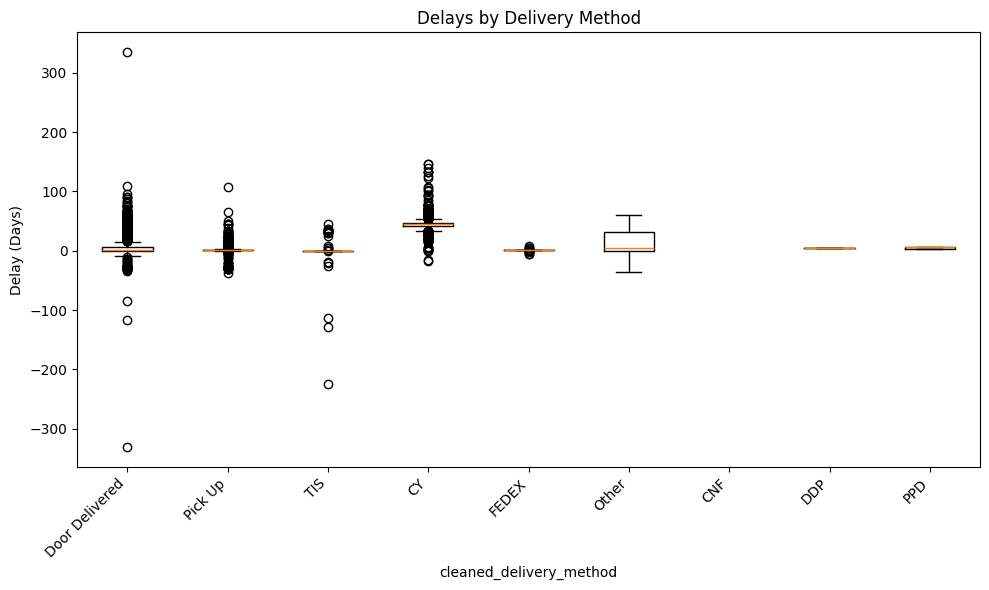

In [34]:
# 2. Box plot of delays by Delivery Method
plot_grouped_box_plot(
    df,
    group_col='cleaned_delivery_method',
    value_col='number_of_days_for_delivery',
    title="Delays by Delivery Method",
    y_label="Delay (Days)"
)

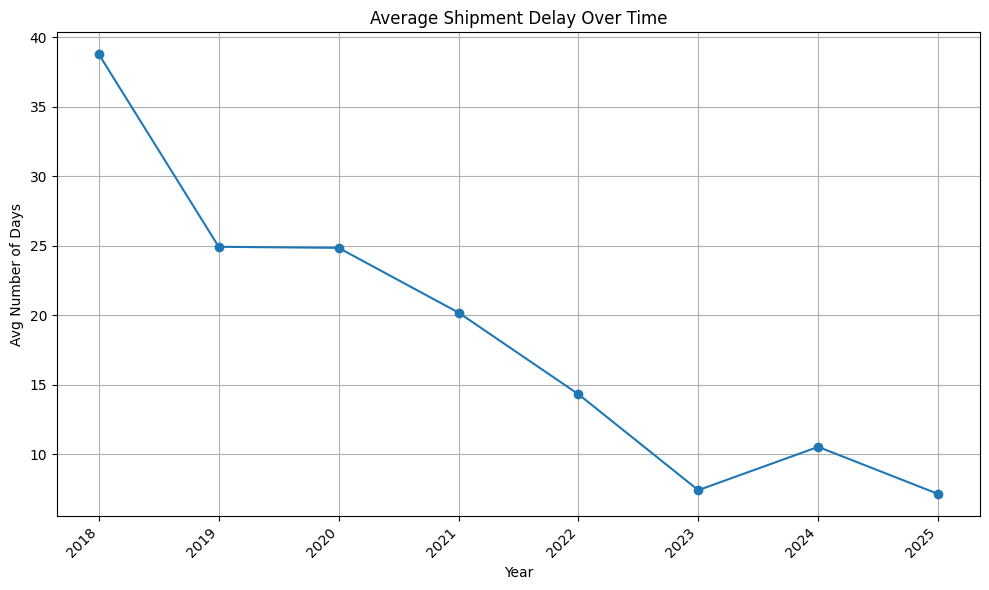

In [35]:
delay_trend = df.groupby(df['order_date'].dt.to_period('Y'))['number_of_days_for_delivery'].mean()
plot_line_graph(
    data_x=delay_trend.index.astype(str),
    data_y=delay_trend.values,
    title="Average Shipment Delay Over Time",
    x_label="Year",
    y_label="Avg Number of Days"
)

In [36]:
df['final_destination'] = df['final_destination'].replace('','No Info')